# 311 Service Requests from Louisville, KY in 2025

Import libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# on initial read of data file, Python informs that the columns listed below in dtype_fix are mixed. 
# so first, we assign them a string datatype. 
dtype_fix = {'source': 'str', 'description': 'str', 'zip_code': 'str', 'council_district': 'str'}
lou311 = pd.read_csv('metro_311_2025.csv', dtype=dtype_fix, parse_dates=['requested_datetime', 'updated_datetime', 'closed_date'])


Inspect the scope and shape of the data

In [2]:
print('Rows, Columns')
print(lou311.shape)

print('====================')

print(lou311.info())

print('====================')

print('# of unique values per column:')
print(lou311.nunique())

print('====================')

print(lou311.head())

Rows, Columns
(182490, 19)
<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   service_request_id  182490 non-null  str           
 1   requested_datetime  182490 non-null  datetime64[us]
 2   probyear            182490 non-null  int64         
 3   updated_datetime    136948 non-null  datetime64[us]
 4   closed_date         122547 non-null  datetime64[us]
 5   status_description  182490 non-null  str           
 6   status_notes        0 non-null       float64       
 7   source              106785 non-null  str           
 8   service_name        182490 non-null  str           
 9   description         115872 non-null  str           
 10  agency_responsible  20296 non-null   str           
 11  address             129116 non-null  str           
 12  longitude           182490 non-null  float64       
 13  latitude     

---
## Data Cleaning

Which columns have missing data?

In [3]:
print(lou311.isnull().sum())

service_request_id         0
requested_datetime         0
probyear                   0
updated_datetime       45542
closed_date            59943
status_description         0
status_notes          182490
source                 75705
service_name               0
description            66618
agency_responsible    162194
address                53374
longitude                  0
latitude                   0
zip_code               55353
council_district       49577
ObjectId                   0
x                          0
y                          0
dtype: int64


**Initial Observations**
* status_notes seems to be an empty column. number of null values equals total number of entries.
* to verify this, we see that service_request_id has zero null values, meaning every row has a service_request_id. so:

In [4]:
print('Total # entries in file: ',lou311['service_request_id'].count())
print('Total null values in status_notes: ', lou311['status_notes'].isnull().sum())
print('Do these numbers match? ', lou311['service_request_id'].count() == lou311['status_notes'].isnull().sum())



Total # entries in file:  182490
Total null values in status_notes:  182490
Do these numbers match?  True


e.g. Drop status_notes from consideration. 
In so doing, start a new cleaned dataframe.

In [5]:
lou311_clean = lou311.drop(labels = 'status_notes', axis='columns')
lou311_clean.columns

Index(['service_request_id', 'requested_datetime', 'probyear',
       'updated_datetime', 'closed_date', 'status_description', 'source',
       'service_name', 'description', 'agency_responsible', 'address',
       'longitude', 'latitude', 'zip_code', 'council_district', 'ObjectId',
       'x', 'y'],
      dtype='str')

---
**Other Columns to Omit?**

While we're at it, the source webpage at data.louisvilleky.gov makes no mention of columns ObjectId, x, or y in the full details page for the 2025 311 data.
A glance at ObjectID reveals it to be a simple counter, and so functionally indistinguishable from the baseline index values.

In [6]:
print(lou311_clean['ObjectId'].head())

0    1
1    2
2    3
3    4
4    5
Name: ObjectId, dtype: int64


e.g. We drop ObjectId as well.

In [7]:
lou311_clean = lou311_clean.drop(labels = 'ObjectId', axis='columns')
lou311_clean.columns

Index(['service_request_id', 'requested_datetime', 'probyear',
       'updated_datetime', 'closed_date', 'status_description', 'source',
       'service_name', 'description', 'agency_responsible', 'address',
       'longitude', 'latitude', 'zip_code', 'council_district', 'x', 'y'],
      dtype='str')

Since the source page also does not mention columns x and y, what can we determine about them? The values they contain do not make it as obvious as it was with ObjectId.
From the .nunique output, we can observe that x has the same number of entries as longitude, and y has the same number of entries as latitude.
Are they, in fact, the same?

In [8]:
print('# of unique values per column:')
print(lou311.nunique())
# sort both x and longitude then compare
x_asc = lou311['x'].sort_values()
long_asc = lou311['longitude'].sort_values()
print('Column x = column longitude: ', x_asc.equals(long_asc))
# sort both y and latitude then compare
y_asc = lou311['y'].sort_values()
lat_asc = lou311['latitude'].sort_values()
print('Column y = column latitude: ', y_asc.equals(lat_asc))

# of unique values per column:
service_request_id    182488
requested_datetime       365
probyear                   1
updated_datetime         447
closed_date              447
status_description         2
status_notes               0
source                     2
service_name              55
description           103137
agency_responsible        35
address                68434
longitude              67199
latitude               67134
zip_code                  43
council_district          28
ObjectId              182490
x                      67199
y                      67134
dtype: int64
Column x = column longitude:  False
Column y = column latitude:  False


x & y are apparently *not* longitude & latitude. 
The number of unique values matching between this pair of pairs is likely more than coincidental. But since we cannot reliably identify *what* they are, they are dropped from the clean data set. We can refer back to the original data set if needed later.

In [9]:
lou311_clean = lou311_clean.drop(labels = ['x', 'y'], axis='columns')
lou311_clean.columns

Index(['service_request_id', 'requested_datetime', 'probyear',
       'updated_datetime', 'closed_date', 'status_description', 'source',
       'service_name', 'description', 'agency_responsible', 'address',
       'longitude', 'latitude', 'zip_code', 'council_district'],
      dtype='str')

Take another look at the current cleaned dataframe:

In [10]:
print(lou311_clean.info())

<class 'pandas.DataFrame'>
RangeIndex: 182490 entries, 0 to 182489
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   service_request_id  182490 non-null  str           
 1   requested_datetime  182490 non-null  datetime64[us]
 2   probyear            182490 non-null  int64         
 3   updated_datetime    136948 non-null  datetime64[us]
 4   closed_date         122547 non-null  datetime64[us]
 5   status_description  182490 non-null  str           
 6   source              106785 non-null  str           
 7   service_name        182490 non-null  str           
 8   description         115872 non-null  str           
 9   agency_responsible  20296 non-null   str           
 10  address             129116 non-null  str           
 11  longitude           182490 non-null  float64       
 12  latitude            182490 non-null  float64       
 13  zip_code            127137 non-null  str

---
**Date Formats**

Several columns represent dates, including requested_datetime, probyear, updated_datetime, and closed_date. 

probyear is simply the year value. In this case, 2025 is the only value in that column, since this is 2025 annual data. We could drop it, but since we may integrate prior years or 2026 YTD later, it should stay.

If we need to examine the relationships between requested_datetime (time the request was made) and updated_datetime (when the request status was updated) or closed_date (date the request was closed), we should probably have pandas read those columns as datetime when reading in the CSV.

*This was completed after this observation was made and can be seen in the first code block of this notebook. This note remains here as a marker of when this was observed.*

---
Are there any truly duplicate rows?

In [11]:
lou311_clean.duplicated().sum()

np.int64(0)

* No duplicate rows.

---
**Further investigation on ZIP codes**
* Many entries are missing zip_code, but no entires are missing latitude or longitude. 
* Can zip_code be derived from latitude/longitude combination? If so, how? 
* Could the same process to backfill zip_code be used for council_district?

In [12]:
# Take a closer look at ZIP code data. 
# How many ZIP codes are represented?
# Which ZIP code is the most frequent user of 311 services?

lou311_clean['zip_code'] = lou311_clean['zip_code'].astype(str)
# print(lou311['zip_code'].dtypes)
# ^^ confirms change of zip_code to string

missing_zips = lou311_clean['zip_code'].isnull().sum()
pct_missing_zips = lou311_clean['zip_code'].isnull().sum() / lou311_clean['service_request_id'].value_counts().sum() * 100

print('# of entries missing ZIP codes: ',  "{:,}".format(missing_zips))
print('% of entries missing ZIP codes: ', "{:.2f}".format(pct_missing_zips), "%")

print("====================")

print(lou311['zip_code'].describe())

print("====================")



# of entries missing ZIP codes:  55,353
% of entries missing ZIP codes:  30.33 %
count     127137
unique        43
top        40211
freq        9612
Name: zip_code, dtype: object


The code below was found as sourced on Stack Overflow.
I will attempt to backfill the missing ZIP codes as follows:
* Create a list variable to house the row index, latitude, and longitude of rows only missing ZIP codes.
* Run the list through the function below, or some version of it.
* Write the function return to another list, then use a for loop to assign the newly identified ZIP codes back to the lou_311_clean dataframe.

In [13]:
# # Source - https://stackoverflow.com/a/66190352
# # Posted by Rafael Valero
# # Retrieved 2026-04-25, License - CC BY-SA 4.0

# import geopy
# import pandas as pd

# longlat = pd.read_csv("longlat.csv",encoding = 'utf-8', sep = '\t')
# geolocator = geopy.Nominatim(user_agent="check_1")

# def get_zip_code(x):
#     location = geolocator.reverse("{}, {}".format(x['LATITUDE_X'],x['LONGITUDE_X']))
#     return location.raw['address']['postcode']
# longlat['zipcode'] = longlat.head().apply(lambda x: get_zip_code(x), axis = 1)
# print(longlat.head())
#    Unnamed: 0  LATITUDE_X  LONGITUDE_X     zipcode
# 0      124148   39.096232   -84.653337  45233-4555
# 1      124209   39.146201   -84.468843       45207
# 2      125298   39.134767   -84.499079       45267
# 3      125299   39.107625   -84.496675       45202
# 4      125390   39.092849   -84.388332       45230


But first we should check to see if the lat/long data for entries missing ZIP codes is legitimate or just filler.

In [14]:
lou311_clean[lou311_clean['zip_code'].isnull()]

,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,source,service_name,description,agency_responsible,address,longitude,latitude,zip_code,council_district
1,SR-MISC-25-000351,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Miscellaneous,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
2,SR-MTRO-25-000250,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
3,SR-MTRO-25-000352,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
5,SR-UTIL-25-000251,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Utility,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
6,SR-MTRO-25-000252,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181968,SR-BAPT-25-112124,2025-07-25 04:00:00,2025,2025-07-25 04:00:00,2025-07-25 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,140-199 N CRESTMOOR AVE,-85.740657,38.283469,NaN,9
182025,SR-MSDS-25-151335,2025-10-10 04:00:00,2025,2025-10-10 04:00:00,NaT,OPEN,NaN,Solid Waste Missed Services,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
182044,SR-SIGN-25-119037,2025-08-07 04:00:00,2025,2025-08-12 04:00:00,2025-08-12 04:00:00,CLOSED,NaN,Street Signs,NaN,NaN,NaN,-85.740657,38.283469,NaN,NaN
182091,SR-BAPT-25-091213,2025-06-17 04:00:00,2025,2025-06-17 04:00:00,2025-06-17 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,NaN,-85.740657,38.283469,NaN,3


At a glance, it looks as though lat/long won't be helpful in backfilling ZIP code after all.
The values are identical for each entry with no included ZIP.

Since I do not expect it would be helpful to drop 55k rows, or nearly one-third of the data, we need an easily identifiable filler for later use in analysis by ZIP.

In [15]:
lou311_clean['zip_code'].unique()

<StringArray>
[     '40217',          nan,      '40210',      '40206',      '40204',
      '40219',      '40216',      '40205',      '40214',      '40212',
      '40207',      '40215',      '40258',      '40228',      '40211',
      '40299',      '40203',      '40213',      '40229',      '40218',
      '40023',      '40220',      '40222',      '40208',      '40291',
      '40272',      '40241',      '40245',      '40223',      '40059',
      '40177',      '40242',      '40118',      '40202',      '40243',
      '40209',      '40225',      '40025', '40219-0000',      '40041',
      '47130', '40207-0000', '40208-0000',      '40165']
Length: 44, dtype: str

We also have some accidental duplicate ZIP codes, i.e. '40207' and '40207-0000', so we will need to deal with those as well.
The most reasonable option is to simply replace the three ZIPs with a '-0000' suffix with their 5-digit base.
And since the ZIP variable is a string, we can replace NaN with "Unknown".

In [16]:
# Consolidate the '-0000' ZIPs into their "correct" counterparts.
lou311_clean.replace({'zip_code': {'40207-0000': '40207', '40208-0000': '40208', '40219-0000': '40219'}}, inplace=True)
lou311_clean['zip_code'].unique()


<StringArray>
['40217',     nan, '40210', '40206', '40204', '40219', '40216', '40205',
 '40214', '40212', '40207', '40215', '40258', '40228', '40211', '40299',
 '40203', '40213', '40229', '40218', '40023', '40220', '40222', '40208',
 '40291', '40272', '40241', '40245', '40223', '40059', '40177', '40242',
 '40118', '40202', '40243', '40209', '40225', '40025', '40041', '47130',
 '40165']
Length: 41, dtype: str

In [17]:
# Ditch the null ZIP codes for 'Unknown'
lou311_clean.fillna({'zip_code': 'Unknown'}, inplace=True)
lou311_clean[lou311_clean['zip_code'].isnull()]
lou311_clean[lou311_clean['zip_code'] == 'Unknown']

,service_request_id,requested_datetime,probyear,updated_datetime,closed_date,status_description,source,service_name,description,agency_responsible,address,longitude,latitude,zip_code,council_district
1,SR-MISC-25-000351,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Miscellaneous,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
2,SR-MTRO-25-000250,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
3,SR-MTRO-25-000352,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
5,SR-UTIL-25-000251,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Utility,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
6,SR-MTRO-25-000252,2025-01-02 05:00:00,2025,NaT,NaT,OPEN,Call Center,NSR Metro Agencies,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181968,SR-BAPT-25-112124,2025-07-25 04:00:00,2025,2025-07-25 04:00:00,2025-07-25 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,140-199 N CRESTMOOR AVE,-85.740657,38.283469,Unknown,9
182025,SR-MSDS-25-151335,2025-10-10 04:00:00,2025,2025-10-10 04:00:00,NaT,OPEN,NaN,Solid Waste Missed Services,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
182044,SR-SIGN-25-119037,2025-08-07 04:00:00,2025,2025-08-12 04:00:00,2025-08-12 04:00:00,CLOSED,NaN,Street Signs,NaN,NaN,NaN,-85.740657,38.283469,Unknown,NaN
182091,SR-BAPT-25-091213,2025-06-17 04:00:00,2025,2025-06-17 04:00:00,2025-06-17 04:00:00,CLOSED,NaN,Large Item Appointment,NaN,NaN,NaN,-85.740657,38.283469,Unknown,3


### Visualizing number of service requests by ZIP code

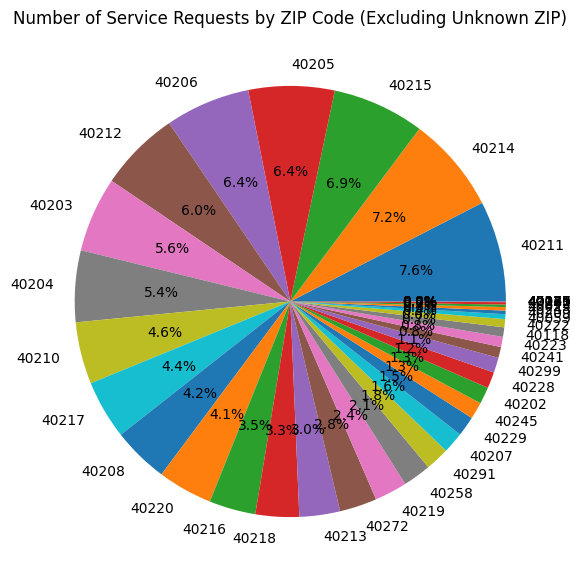

In [18]:
# count requests by ZIP code
tot_sr_zip = lou311_clean.value_counts(subset='zip_code').drop('Unknown')

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart, exclude "Unknown" ZIP
plt.pie(tot_sr_zip, 
        autopct='%1.1f%%',
        labels=tot_sr_zip.index)
plt.title('Number of Service Requests by ZIP Code (Excluding Unknown ZIP)')
plt.show()

In [19]:
lou311_clean['zip_code'].unique()

<StringArray>
[  '40217', 'Unknown',   '40210',   '40206',   '40204',   '40219',   '40216',
   '40205',   '40214',   '40212',   '40207',   '40215',   '40258',   '40228',
   '40211',   '40299',   '40203',   '40213',   '40229',   '40218',   '40023',
   '40220',   '40222',   '40208',   '40291',   '40272',   '40241',   '40245',
   '40223',   '40059',   '40177',   '40242',   '40118',   '40202',   '40243',
   '40209',   '40225',   '40025',   '40041',   '47130',   '40165']
Length: 41, dtype: str

Crowded view with 40 ZIP codes represented, exluding 'Unknown'. Let's trim it down to the top 10 ZIPs by number of requests made.

In [20]:

top_sr_zip = tot_sr_zip.drop('Unknown').nlargest(10)

# set a reasonable plot size
plt.figure(figsize=(7,7))

# plot a pie chart
plt.pie(top_sr_zip, 
        labels=top_sr_zip.index, 
        autopct='%1.1f%%',
        colors=sns.color_palette('tab10'))
plt.title('Top 10 Most Service Requests by ZIP Code (Excluding Unknown ZIP)')
plt.show()


KeyError: "['Unknown'] not found in axis"

This is kind of pretty, but doesn't inform too terribly much about relative volume of service requests by ZIP code.
A bar chart might be more informative?

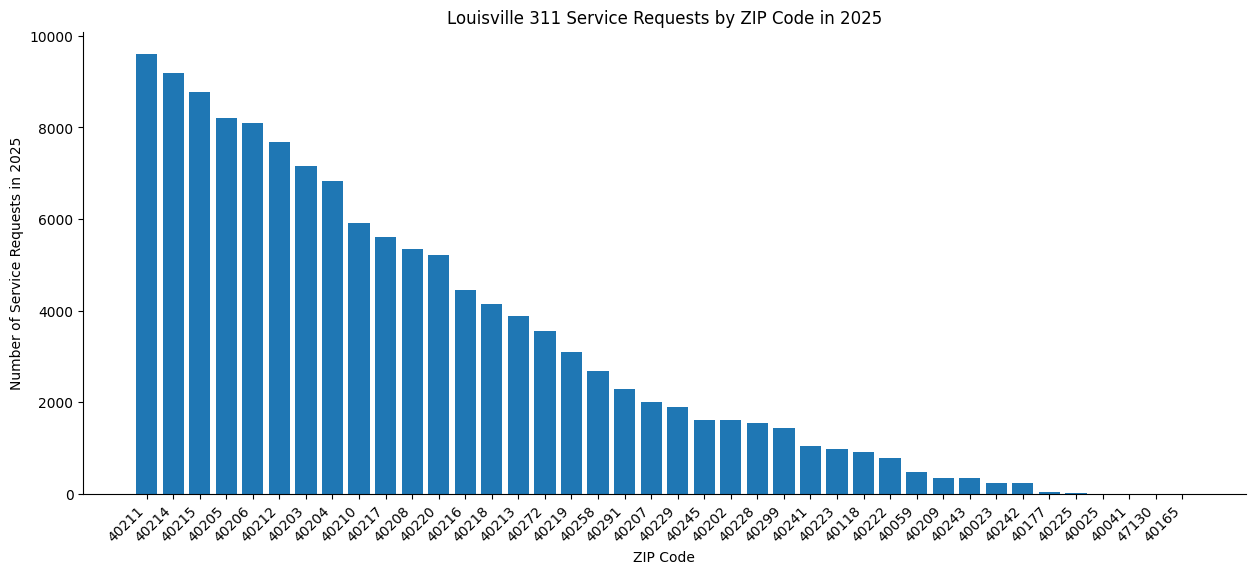

In [ ]:
# set a reasonable plot size
plt.figure(figsize=(15,6))

# make it more readable
plt.xlabel("ZIP Code")
plt.ylabel("Number of Service Requests in 2025")
plt.title("Louisville 311 Service Requests by ZIP Code in 2025")
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.bar(tot_sr_zip.index,tot_sr_zip.values)

plt.show()


---
### So what have we gleaned from ZIP code?

Less than I was hoping, it seems. 

I suspect it may be time to step back to look at some other variables in this dataset.

Most of them are strings, which reduces quantitative analysis to various counts, which is perhaps where I should have started anyway. 

So let's begin again by looking at unique values by category.

In [27]:
# print(lou311_clean.info())
print("Number of unique 'service_name': ", lou311_clean['service_name'].nunique())
print("Number of unique 'status_description': ", lou311_clean['status_description'].nunique())
print("Number of unique 'description': ", lou311_clean['description'].nunique())
print("Number of unique 'agency_responsible': ", lou311_clean['agency_responsible'].nunique())
print("Number of unique 'source': ", lou311_clean['source'].nunique())
print("Number of unique 'council_district': ", lou311_clean['council_district'].nunique())


Number of unique 'service_name':  55
Number of unique 'status_description':  2
Number of unique 'description':  103137
Number of unique 'agency_responsible':  35
Number of unique 'source':  2
Number of unique 'council_district':  28
